In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [66]:
df = pd.read_csv('../data/raw/RAW_recipes.csv', nrows=20000)
df.head()

,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
0,arriba baked winter squash mexican style,137739,55,47892,2005-09-16,"['60-minutes-or-less', 'time-to-make', 'course...","[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]",11,"['make a choice and proceed with recipe', 'dep...",autumn is my favorite time of year to cook! th...,"['winter squash', 'mexican seasoning', 'mixed ...",7
1,a bit different breakfast pizza,31490,30,26278,2002-06-17,"['30-minutes-or-less', 'time-to-make', 'course...","[173.4, 18.0, 0.0, 17.0, 22.0, 35.0, 1.0]",9,"['preheat oven to 425 degrees f', 'press dough...",this recipe calls for the crust to be prebaked...,"['prepared pizza crust', 'sausage patty', 'egg...",6
2,all in the kitchen chili,112140,130,196586,2005-02-25,"['time-to-make', 'course', 'preparation', 'mai...","[269.8, 22.0, 32.0, 48.0, 39.0, 27.0, 5.0]",6,"['brown ground beef in large pot', 'add choppe...",this modified version of 'mom's' chili was a h...,"['ground beef', 'yellow onions', 'diced tomato...",13
3,alouette potatoes,59389,45,68585,2003-04-14,"['60-minutes-or-less', 'time-to-make', 'course...","[368.1, 17.0, 10.0, 2.0, 14.0, 8.0, 20.0]",11,['place potatoes in a large pot of lightly sal...,"this is a super easy, great tasting, make ahea...","['spreadable cheese with garlic and herbs', 'n...",11
4,amish tomato ketchup for canning,44061,190,41706,2002-10-25,"['weeknight', 'time-to-make', 'course', 'main-...","[352.9, 1.0, 337.0, 23.0, 3.0, 0.0, 28.0]",5,['mix all ingredients& boil for 2 1 / 2 hours ...,my dh's amish mother raised him on this recipe...,"['tomato juice', 'apple cider vinegar', 'sugar...",8


In [67]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   name            19999 non-null  str  
 1   id              20000 non-null  int64
 2   minutes         20000 non-null  int64
 3   contributor_id  20000 non-null  int64
 4   submitted       20000 non-null  str  
 5   tags            20000 non-null  str  
 6   nutrition       20000 non-null  str  
 7   n_steps         20000 non-null  int64
 8   steps           20000 non-null  str  
 9   description     19519 non-null  str  
 10  ingredients     20000 non-null  str  
 11  n_ingredients   20000 non-null  int64
dtypes: int64(5), str(7)
memory usage: 1.8 MB


name                1
id                  0
minutes             0
contributor_id      0
submitted           0
tags                0
nutrition           0
n_steps             0
steps               0
description       481
ingredients         0
n_ingredients       0
dtype: int64

In [68]:
print(df['tags'].iloc[0])
print(df['ingredients'].iloc[0])

['60-minutes-or-less', 'time-to-make', 'course', 'main-ingredient', 'cuisine', 'preparation', 'occasion', 'north-american', 'side-dishes', 'vegetables', 'mexican', 'easy', 'fall', 'holiday-event', 'vegetarian', 'winter', 'dietary', 'christmas', 'seasonal', 'squash']
['winter squash', 'mexican seasoning', 'mixed spice', 'honey', 'butter', 'olive oil', 'salt']


In [69]:
# Look at tags from 5 different recipes to spot the cuisine-related ones
for i in range(5):
    print(df['tags'].iloc[i])
    print('---')

['60-minutes-or-less', 'time-to-make', 'course', 'main-ingredient', 'cuisine', 'preparation', 'occasion', 'north-american', 'side-dishes', 'vegetables', 'mexican', 'easy', 'fall', 'holiday-event', 'vegetarian', 'winter', 'dietary', 'christmas', 'seasonal', 'squash']
---
['30-minutes-or-less', 'time-to-make', 'course', 'main-ingredient', 'cuisine', 'preparation', 'occasion', 'north-american', 'breakfast', 'main-dish', 'pork', 'american', 'oven', 'easy', 'kid-friendly', 'pizza', 'dietary', 'northeastern-united-states', 'meat', 'equipment']
---
['time-to-make', 'course', 'preparation', 'main-dish', 'chili', 'crock-pot-slow-cooker', 'dietary', 'equipment', '4-hours-or-less']
---
['60-minutes-or-less', 'time-to-make', 'course', 'main-ingredient', 'preparation', 'occasion', 'side-dishes', 'eggs-dairy', 'potatoes', 'vegetables', 'oven', 'easy', 'dinner-party', 'holiday-event', 'easter', 'cheese', 'stove-top', 'dietary', 'christmas', 'new-years', 'thanksgiving', 'independence-day', 'st-patrick

In [70]:
# Common cuisine-related tags to look for
cuisine_keywords = ['mexican', 'american', 'italian', 'chinese', 'french', 
                     'indian', 'thai', 'japanese', 'greek', 'spanish', 
                     'german', 'korean', 'vietnamese', 'moroccan', 'cajun',
                     'southern', 'mediterranean', 'caribbean', 'african']

def extract_cuisine(tags_str):
    for keyword in cuisine_keywords:
        if keyword in tags_str:
            return keyword
    return None

df['cuisine'] = df['tags'].apply(extract_cuisine)
df['cuisine'].value_counts()

cuisine
american      3972
italian        506
mexican        474
african        246
indian         180
french         126
greek          121
german         119
chinese        114
spanish         78
thai            46
japanese        39
moroccan        27
vietnamese      13
korean           6
Name: count, dtype: int64

In [71]:
cuisine_counts = df['cuisine'].value_counts()
valid_cuisines = cuisine_counts[cuisine_counts >= 100].index

df_filtered = df[df['cuisine'].isin(valid_cuisines)].copy()
df_filtered['cuisine'].value_counts()

cuisine
american    3972
italian      506
mexican      474
african      246
indian       180
french       126
greek        121
german       119
chinese      114
Name: count, dtype: int64

In [72]:
import ast

# Convert the string representation of a list into an actual list
df_filtered['ingredients_list'] = df_filtered['ingredients'].apply(ast.literal_eval)

# Check it worked
df_filtered['ingredients_list'].iloc[0]

['winter squash',
 'mexican seasoning',
 'mixed spice',
 'honey',
 'butter',
 'olive oil',
 'salt']

In [73]:
from collections import Counter

# Build ingredient frequency counts for each cuisine
cuisine_ingredients = {}

for cuisine in df_filtered['cuisine'].unique():
    subset = df_filtered[df_filtered['cuisine'] == cuisine]
    all_ingredients = [ing for ing_list in subset['ingredients_list'] for ing in ing_list]
    cuisine_ingredients[cuisine] = Counter(all_ingredients)

# Show the top 10 ingredients for each cuisine
for cuisine, counter in cuisine_ingredients.items():
    print(f"\n{cuisine.upper()}:")
    for ingredient, count in counter.most_common(10):
        print(f"  {ingredient}: {count}")


MEXICAN:
  salt: 175
  onion: 134
  garlic cloves: 87
  olive oil: 83
  sour cream: 79
  water: 76
  chili powder: 70
  tomatoes: 67
  fresh cilantro: 64
  garlic: 64

AMERICAN:
  salt: 1536
  butter: 984
  sugar: 757
  onion: 669
  eggs: 587
  water: 586
  flour: 519
  milk: 493
  brown sugar: 489
  olive oil: 403

INDIAN:
  salt: 107
  water: 54
  onion: 53
  garam masala: 44
  oil: 41
  turmeric: 37
  garlic cloves: 34
  tomatoes: 31
  potatoes: 29
  ground coriander: 28

GERMAN:
  salt: 62
  sugar: 51
  butter: 49
  flour: 34
  eggs: 34
  milk: 27
  onion: 27
  water: 24
  cinnamon: 23
  apples: 18

ITALIAN:
  olive oil: 198
  salt: 193
  parmesan cheese: 188
  garlic cloves: 126
  onion: 112
  butter: 108
  mozzarella cheese: 94
  eggs: 78
  garlic: 76
  extra virgin olive oil: 73

CHINESE:
  soy sauce: 56
  salt: 41
  sesame oil: 36
  sugar: 31
  water: 29
  garlic cloves: 27
  cornstarch: 27
  vegetable oil: 25
  fresh ginger: 18
  green onions: 17

FRENCH:
  salt: 44
  butter:

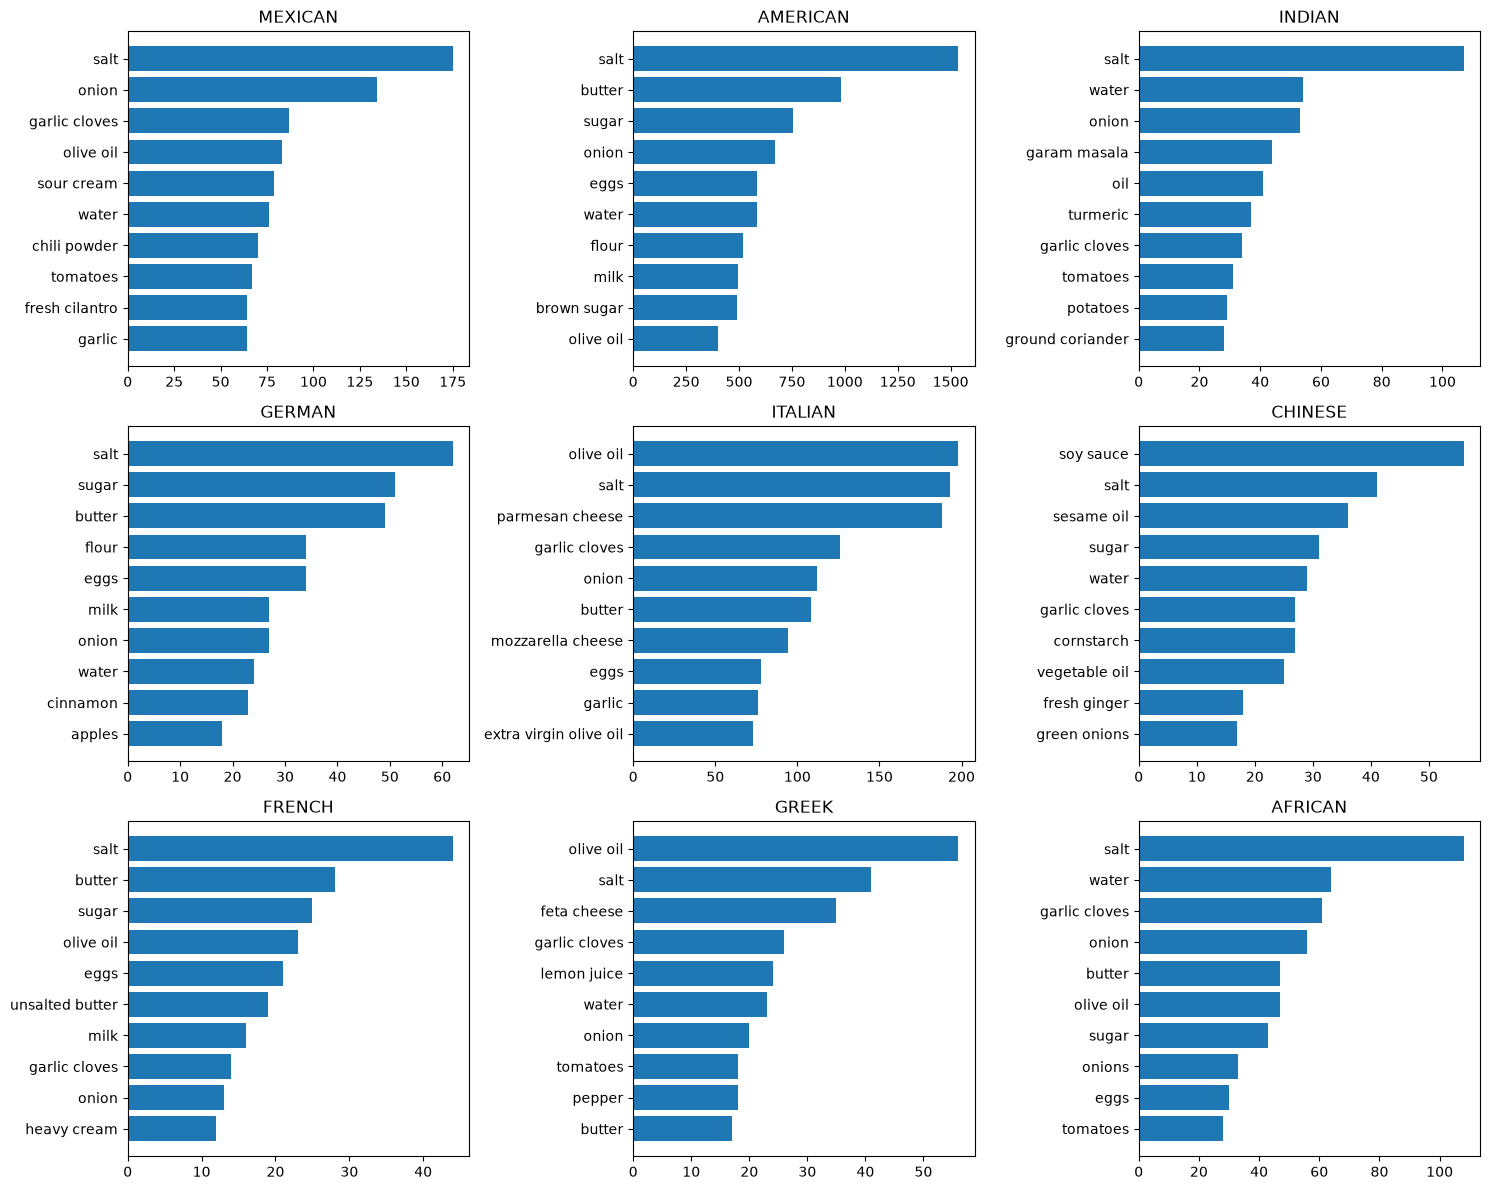

In [74]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for idx, (cuisine, counter) in enumerate(cuisine_ingredients.items()):
    top_10 = counter.most_common(10)
    ingredients, counts = zip(*top_10)
    
    axes[idx].barh(ingredients, counts)
    axes[idx].set_title(cuisine.upper())
    axes[idx].invert_yaxis()

plt.tight_layout()
plt.savefig('../images/top_ingredients_by_cuisine.png')
plt.show()

In [75]:
from itertools import combinations

def jaccard_similarity(set1, set2):
    intersection = len(set1 & set2)
    union = len(set1 | set2)
    return intersection / union

# Build a set of unique ingredients per cuisine (ignoring frequency, just presence)
cuisine_ingredient_sets = {
    cuisine: set(counter.keys()) 
    for cuisine, counter in cuisine_ingredients.items()
}

# Compare every pair of cuisines
results = []
for c1, c2 in combinations(cuisine_ingredient_sets.keys(), 2):
    score = jaccard_similarity(cuisine_ingredient_sets[c1], cuisine_ingredient_sets[c2])
    results.append((c1, c2, score))

# Sort by most similar first
results.sort(key=lambda x: x[2], reverse=True)

for c1, c2, score in results:
    print(f"{c1} vs {c2}: {score:.3f}")

indian vs african: 0.280
french vs greek: 0.260
mexican vs african: 0.257
italian vs greek: 0.245
italian vs african: 0.238
greek vs african: 0.237
german vs french: 0.232
italian vs french: 0.225
mexican vs american: 0.225
mexican vs italian: 0.224
indian vs greek: 0.222
french vs african: 0.217
german vs greek: 0.209
mexican vs indian: 0.205
german vs african: 0.200
chinese vs african: 0.198
american vs italian: 0.198
mexican vs greek: 0.197
indian vs german: 0.191
indian vs chinese: 0.191
german vs italian: 0.188
indian vs french: 0.180
chinese vs greek: 0.178
mexican vs french: 0.178
indian vs italian: 0.169
mexican vs german: 0.168
german vs chinese: 0.167
mexican vs chinese: 0.163
american vs african: 0.155
chinese vs french: 0.154
italian vs chinese: 0.151
american vs french: 0.114
american vs indian: 0.107
american vs greek: 0.100
american vs german: 0.096
american vs chinese: 0.090


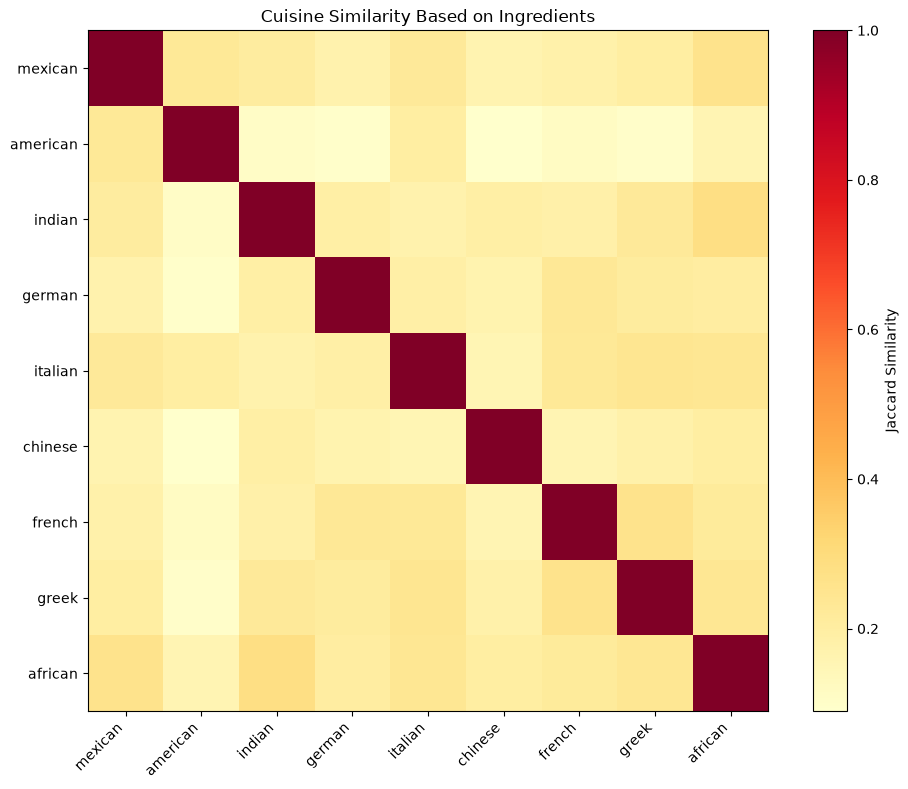

In [76]:
import numpy as np

cuisines = list(cuisine_ingredient_sets.keys())
n = len(cuisines)
matrix = np.zeros((n, n))

for i, c1 in enumerate(cuisines):
    for j, c2 in enumerate(cuisines):
        if i == j:
            matrix[i][j] = 1.0
        else:
            matrix[i][j] = jaccard_similarity(cuisine_ingredient_sets[c1], cuisine_ingredient_sets[c2])

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(matrix, cmap='YlOrRd')
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(cuisines, rotation=45, ha='right')
ax.set_yticklabels(cuisines)
plt.colorbar(im, label='Jaccard Similarity')
plt.title('Cuisine Similarity Based on Ingredients')
plt.tight_layout()
plt.savefig('../images/cuisine_similarity_heatmap.png')
plt.show()